## Weather data

Most crop simulations require weather input data. Most commonly:
    - Solar irradiance (MJ/m2/day)
    - Precipation (mm/month)
    
And less important
    - Days with rain (1/month)
    
This demo comes with weather data files which can be found in the inputs folder.
    
**Note, these input files can for instance be opened/altered in Excel.**

In [1]:
# import pandas --- spreadsheet library
import pandas as pd

# import matplotlib --- plotting library
import matplotlib.pyplot as plt 

# read-in the csv-file
weather_data = pd.read_csv('./input/bangladesh.csv',index_col='Date')
weather_data.index = pd.to_datetime(weather_data.index, errors='coerce')

#### Note the quite variable solar radiation

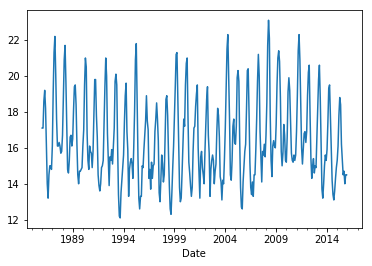

In [2]:
weather_data['Solar (MJ/m2)'].plot()

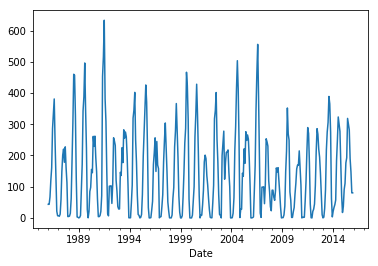

In [3]:
weather_data['Precip (mm)'].plot()

In [4]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

year_of_planting = weather_data.index.year[0]

# 1. Initialize the model
p = PalmField(year_of_planting=year_of_planting)

# 2. Couple the solar radiation data:
p.weather.radiation = weather_data['Solar (MJ/m2)'].resample('D').pad().mean()

s = weather_data['Precip (mm)'].resample('D').pad()
s = s/s.index.days_in_month

#p.weather.rainfall_series = s

In [5]:
import time
import tqdm

In [6]:
t0 = time.time()

dt = 10

p.dt = dt

nyears = 30

duration = nyears*365
nsteps = duration//dt

res = {}

for i in tqdm.tqdm(range(nsteps)):
    
    p.update(dt=dt)
    
    res[i] = p.to_dict()
    
t1 = time.time()

print(t1 - t0)

100%|█████████████████████████████████████| 1095/1095 [00:08<00:00, 122.65it/s]


8.939799785614014


In [7]:
import pandas as pd

df = pd.DataFrame(res).T

In [8]:
df = df.set_index(pd.to_datetime(df['date']))

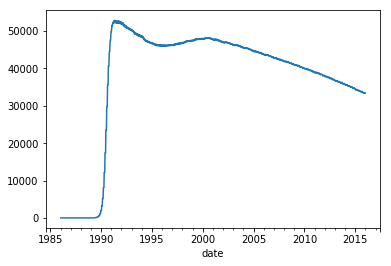

In [9]:
df['generative_FFB_production (t/ha/yr)'].plot()

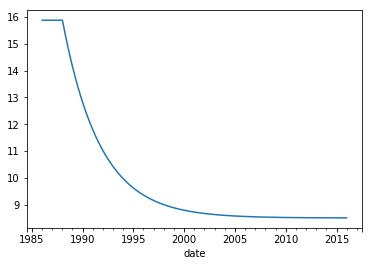

In [10]:
df['fronds_count_growth_rate (1/ha/day)'].plot()

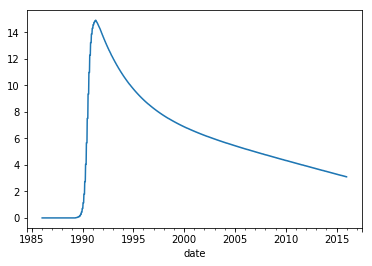

In [11]:
df['generative_bunch_count (1/ha/day)'].plot()

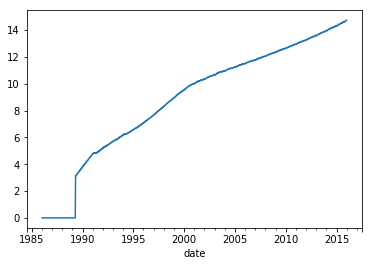

In [12]:
df['generative_bunch_weight (kg_DM)'].plot()

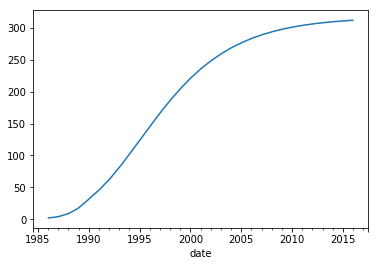

In [13]:
df['trunk_mass_per_palm (kg_DM/palm)'].plot()

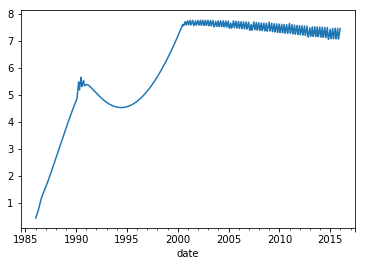

In [14]:
df['fronds_leaf_area_index (1)'].plot()

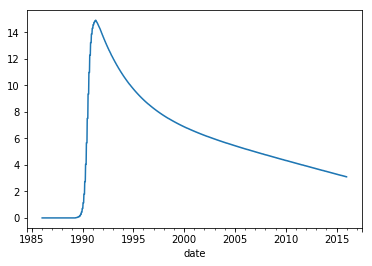

In [15]:
df['generative_bunch_count (1/ha/day)'].plot()

In [16]:
p.generative.cohorts[0]

Object: Female

Property                                     Value Unit        
--------------------------------------------------------------
Ic                                           0.000  1           
abortion_fraction                            0.000  1           
age                                       1200.000  day         
assim_growth_cohort                          0.000  kg_CH2O/cohort/day
assim_growth_organ                           0.000  kg_CH2O/organ/day
bunch_failure_fraction                       0.000  1           
has_flowered                                 1.000  bool        
inflorescence_abortion_fraction              0.000  1           
is_deletable                                 0.000  bool        
is_harvestible                               1.000  bool        
maintenance_requirement                      0.032  kg_CH2O/organ/day
mass                                        14.734  kg_DM       
mass_growth_rate                             0.000  kg_DM/day

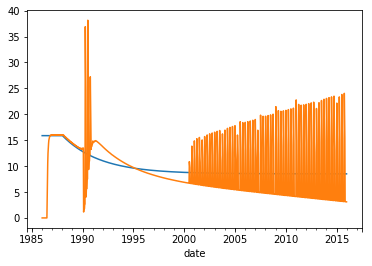

In [17]:
df['fronds_count_growth_rate (1/ha/day)'].plot()
df['fronds_count_loss_rate (1/ha/day)'].plot()

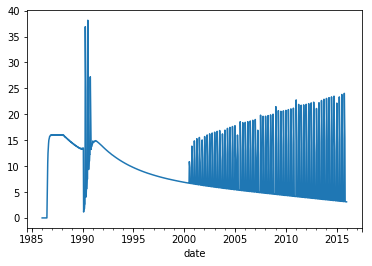

In [18]:
df['management_prune_rate (1/ha/day)'].plot()

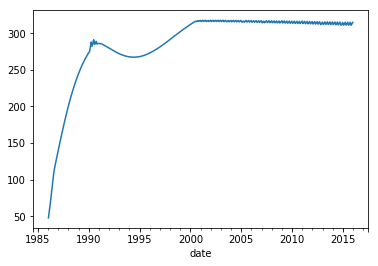

In [19]:
df['fronds_assim_produced (kg_CH2O/ha/day)'].plot()

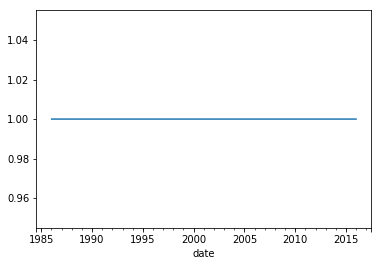

In [20]:
df['soil_moisture_content (1)'].plot()

In [21]:
p.weather

Object: Weather

Property                                     Value Unit        
--------------------------------------------------------------
PAR                                          8.252  MJ/m2/day   
radiation                                   16.504  MJ/m2/day   
radiation_series_mean                       16.504  MJ/m2/day   
raindays                                    14.000  1/mo        
raindays_series_mean                        14.000  1/mo        
rainfall                                   150.000  mm/day      
rainfall_series_mean                       150.000  mm/day      

In [22]:
p.date_tuple

(2015, 12, 25)

In [23]:
p.trunk.mass, p.trunk.mass_change_rate

(43079.07454086566, 0.4166943310660034)

In [24]:
p.roots.mass, p.roots.mass_change_rate

(16832.9570350399, 0.7699245335004914)

In [25]:
p.fronds.mass, p.fronds.mass_change_rate

(12013.070902426587, 10.536160302528977)

In [26]:
p.assimilates.assim_produced, p.assimilates.assim_growth_total

(314.340186534526, 148.78472754982766)

In [27]:
p.fronds

Object: Fronds

Property                                     Value Unit        
--------------------------------------------------------------
LUE                                          4.200  g_CH2O/MJ PAR
assim_growth                                24.038  kg_CH2O/ha/day
assim_produced                             314.980  kg_CH2O/ha/day
count                                     6156.476  1/ha        
count_change_rate                            5.402  1/ha/day    
count_growth_rate                            8.503  1/ha/day    
count_loss_rate                              3.101  1/ha/day    
count_per_palm                              44.612  1/palm      
fraction_intercepted                         0.915  1           
initiation_rate                              0.062  1/palm/day  
intercepted_PAR                             75.501  GJ/ha/day   
leaf_area_index                              7.467  1           
leaf_area_per_palm                         541.118  m2          
mainten

In [28]:
p.generative

Object: Cohorts

Property                                     Value Unit        
--------------------------------------------------------------
CPO_production                              18.360  kg_DM/ha/day
EFB_production                              24.981  kg_DM/ha/day
FFB_production                           33349.390  t/ha/yr     
PKO_production                               2.343  kg_DM/ha/day
assim_growth                               109.855  kg_DM/ha/day
assim_growth_females                        72.776  kg_CH2O/ha/day
assim_growth_indeterminates                 37.079  kg_CH2O/ha/day
assim_growth_males                           0.000  kg_CH2O/ha/day
bunch_count                                  3.101  1/ha/day    
bunch_failure_fraction                       0.000  1           
bunch_production                            45.684  kg_DM/ha/day
bunch_weight                                14.734  kg_DM       
bunch_weight_fresh                          29.467  kg          
femal

In [29]:
p.soil.available_water, p.soil.available_water_change_rate,

(400.0, 0.0)

In [30]:
p.assimilates

Object: Assimilates

Property                                     Value Unit        
--------------------------------------------------------------
assim_growth_fronds                         24.038  kg_CH2O/ha/day
assim_growth_generative                    109.855  kg_CH2O/ha/day
assim_growth_roots                          14.288  kg_CH2O/ha/day
assim_growth_total                         148.785  kg_CH2O/ha/day
assim_growth_trunk                           0.604  kg_CH2O/ha/day
assim_growth_vegetative                     38.930  kg_CH2O/ha/day
assim_maintenance_fronds                    42.570  kg_CH2O/ha/day
assim_maintenance_generative                64.432  kg_CH2O/ha/day
assim_maintenance_roots                     37.015  kg_CH2O/ha/day
assim_maintenance_total                    165.555  kg_CH2O/ha/day
assim_maintenance_trunk                     21.537  kg_CH2O/ha/day
assim_maintenance_vegetative               101.123  kg_CH2O/ha/day
assim_produced                             314.3

In [31]:
cohort = p.generative.cohorts[0]

In [32]:
cohort

Object: Female

Property                                     Value Unit        
--------------------------------------------------------------
Ic                                           0.000  1           
abortion_fraction                            0.000  1           
age                                       1200.000  day         
assim_growth_cohort                          0.000  kg_CH2O/cohort/day
assim_growth_organ                           0.000  kg_CH2O/organ/day
bunch_failure_fraction                       0.000  1           
has_flowered                                 1.000  bool        
inflorescence_abortion_fraction              0.000  1           
is_deletable                                 0.000  bool        
is_harvestible                               1.000  bool        
maintenance_requirement                      0.032  kg_CH2O/organ/day
mass                                        14.734  kg_DM       
mass_growth_rate                             0.000  kg_DM/day